# AQI Predictor: Exploratory Data Analysis

This notebook explores the backfilled feature dataset used to train the AQI forecasting models: `aqi_features_final.csv`, covering 5 Pakistani cities (Karachi, Lahore, Islamabad, Faisalabad, Peshawar) over roughly 2 years of hourly weather and pollutant data.

Goals:
- Understand the AQI distribution and how it differs by city
- Identify seasonal and daily trends in pollution
- Check how pollutants relate to each other and to AQI
- Check how predictable AQI is from its own recent history (this justifies the persistence baseline used in `train.py`)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (11, 5)

df = pd.read_csv("../data/aqi_features_final.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["city", "timestamp"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()


Rows: 84,362
Cities: ['Faisalabad', 'Islamabad', 'Karachi', 'Lahore', 'Peshawar']
Date range: 2024-07-31 17:00:00 to 2026-07-28 21:26:25


,city,timestamp,hour,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos,temp,...,pm2_5_lag_1h,pm2_5_lag_3h,pm2_5_lag_24h,pm2_5_roll_3h,pm2_5_roll_6h,pm2_5_roll_24h,aqi,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,Faisalabad,2024-07-31 17:00:00,17,2,7,-0.965926,-2.588190e-01,0.974928,-0.222521,32.3,...,NaN,NaN,NaN,20.470000,20.470000,20.470000,72,61.0,152.0,85.0
1,Faisalabad,2024-07-31 18:00:00,18,2,7,-1.000000,-1.836970e-16,0.974928,-0.222521,32.0,...,20.47,NaN,NaN,21.345000,21.345000,21.345000,75,63.0,152.0,97.0
2,Faisalabad,2024-07-31 19:00:00,19,2,7,-0.965926,2.588190e-01,0.974928,-0.222521,32.1,...,22.22,NaN,NaN,22.453333,22.453333,22.453333,80,64.0,139.0,113.0
3,Faisalabad,2024-07-31 20:00:00,20,2,7,-0.866025,5.000000e-01,0.974928,-0.222521,32.0,...,24.67,20.47,NaN,24.303333,23.345000,23.345000,82,63.0,115.0,127.0
4,Faisalabad,2024-07-31 21:00:00,21,2,7,-0.707107,7.071068e-01,0.974928,-0.222521,30.9,...,26.02,22.22,NaN,25.696667,23.956000,23.956000,83,64.0,95.0,137.0


## 1. Dataset overview

In [ ]:
print("Rows per city:")
print(df["city"].value_counts())

print("\nMissing values (non-zero columns only):")
nulls = df.isnull().sum()
print(nulls[nulls > 0])

print("\nDuplicate (city, timestamp) pairs:", df.duplicated(subset=["city", "timestamp"]).sum())


Rows per city:
city
Faisalabad    16882
Islamabad     16882
Karachi       16882
Lahore        16858
Peshawar      16858
Name: count, dtype: int64

Missing values (non-zero columns only):
pm2_5_lag_1h        5
pm2_5_lag_3h       15
pm2_5_lag_24h     120
target_aqi_24h    120
target_aqi_48h    240
target_aqi_72h    360
dtype: int64

Duplicate (city, timestamp) pairs: 0


Missing values only show up in the lag/rolling/target columns, which is expected: the first 24 hours of each city's history don't have a 24h lag yet, and the last 72 hours don't have a target 72h ahead yet. These edge rows get dropped before training (`train.py`'s `load_clean_data`), so this isn't data quality noise, it's structural.

In [ ]:
df[["pm2_5", "pm10", "co", "no2", "o3", "so2", "aqi"]].describe().round(1)


,pm2_5,pm10,co,no2,o3,so2,aqi
count,84362.0,84362.0,84362.0,84362.0,84362.0,84362.0,84362.0
mean,93.2,136.6,1194.5,25.2,74.1,7.3,166.6
std,108.3,124.4,1590.1,117.4,49.9,10.4,110.6
min,0.0,0.0,62.7,-9999.0,0.0,0.1,0.0
25%,30.4,59.9,304.0,2.8,38.2,1.7,91.0
50%,54.0,96.9,572.4,9.6,67.7,3.7,147.0
75%,107.7,163.8,1348.5,24.6,109.1,8.3,188.0
max,1308.8,1469.4,14953.6,444.2,572.2,165.9,500.0


## 2. AQI distribution overall and by city

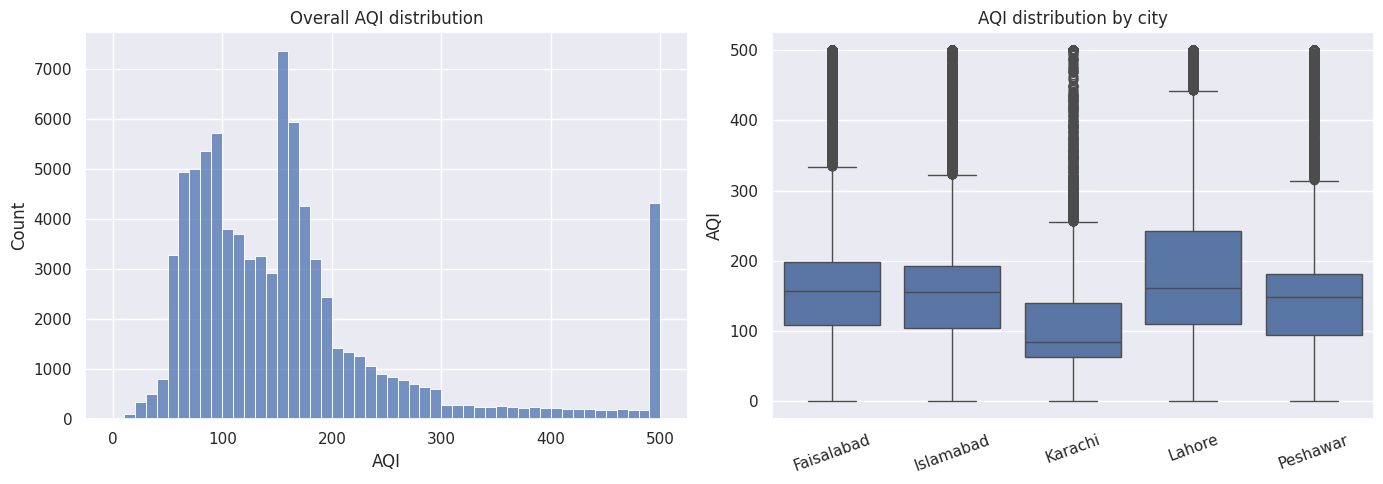

             mean  median    std  max
city                                 
Lahore      204.5   161.0  131.1  500
Faisalabad  185.1   157.0  114.0  500
Islamabad   170.5   155.0   97.6  500
Peshawar    161.7   148.0  100.5  500
Karachi     111.2    84.0   80.7  500


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["aqi"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Overall AQI distribution")
axes[0].set_xlabel("AQI")

sns.boxplot(data=df, x="city", y="aqi", ax=axes[1])
axes[1].set_title("AQI distribution by city")
axes[1].set_xlabel("")
axes[1].set_ylabel("AQI")
plt.setp(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()

print(df.groupby("city")["aqi"].agg(["mean", "median", "std", "max"]).round(1).sort_values("mean", ascending=False))


AQI in this dataset skews high across all five cities, medians sit well into "Unhealthy for Sensitive Groups" or worse on the US EPA scale, which matches Pakistan's known air quality profile rather than looking like a data problem. Worth calling out explicitly in the report, since a reader unfamiliar with the region might otherwise assume something's wrong with the pipeline.

## 3. AQI category breakdown

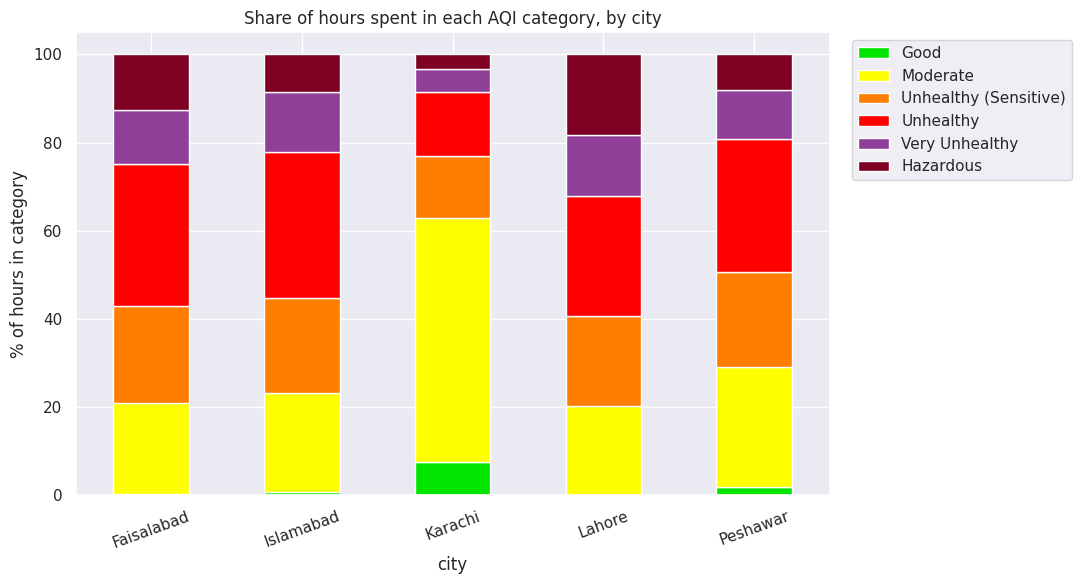

aqi_category,Good,Moderate,Unhealthy (Sensitive),Unhealthy,Very Unhealthy,Hazardous
city,,,,,,
Faisalabad,0.3,20.8,22.0,32.2,12.1,12.6
Islamabad,0.8,22.4,21.5,33.2,13.5,8.5
Karachi,7.7,55.2,13.9,14.6,5.2,3.3
Lahore,0.2,20.1,20.4,27.3,13.8,18.2
Peshawar,2.0,27.1,21.7,30.1,11.1,8.0


In [ ]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy (Sensitive)"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

category_order = ["Good", "Moderate", "Unhealthy (Sensitive)", "Unhealthy", "Very Unhealthy", "Hazardous"]
df["aqi_category"] = pd.Categorical(df["aqi"].apply(aqi_category), categories=category_order, ordered=True)

city_cat = pd.crosstab(df["city"], df["aqi_category"], normalize="index") * 100
city_cat = city_cat[category_order]

city_cat.plot(kind="bar", stacked=True, figsize=(11, 6),
              color=["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"])
plt.ylabel("% of hours in category")
plt.title("Share of hours spent in each AQI category, by city")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

city_cat.round(1)


## 4. Seasonal trend: average AQI by month

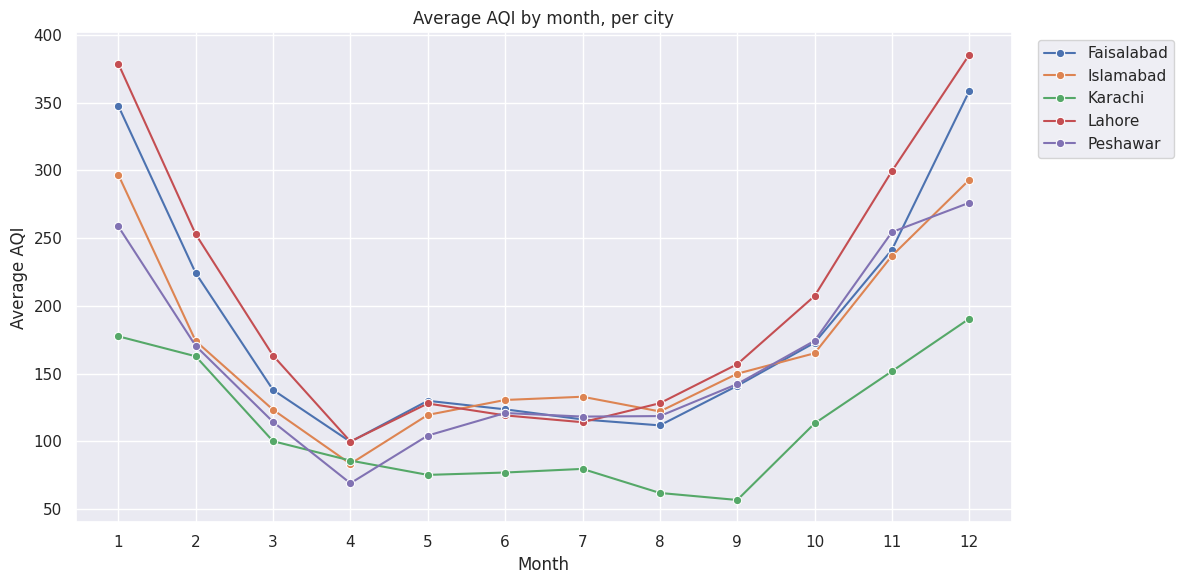

In [ ]:
monthly = df.groupby(["city", "month"])["aqi"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="month", y="aqi", hue="city", marker="o")
plt.title("Average AQI by month, per city")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


If a clear winter peak shows up here (roughly Nov-Feb), that lines up with the known crop-burning and temperature-inversion season across Punjab and Islamabad specifically, and is worth naming directly in the report as a sanity check that the data reflects real-world seasonality rather than noise.

## 5. Daily pattern: average AQI by hour

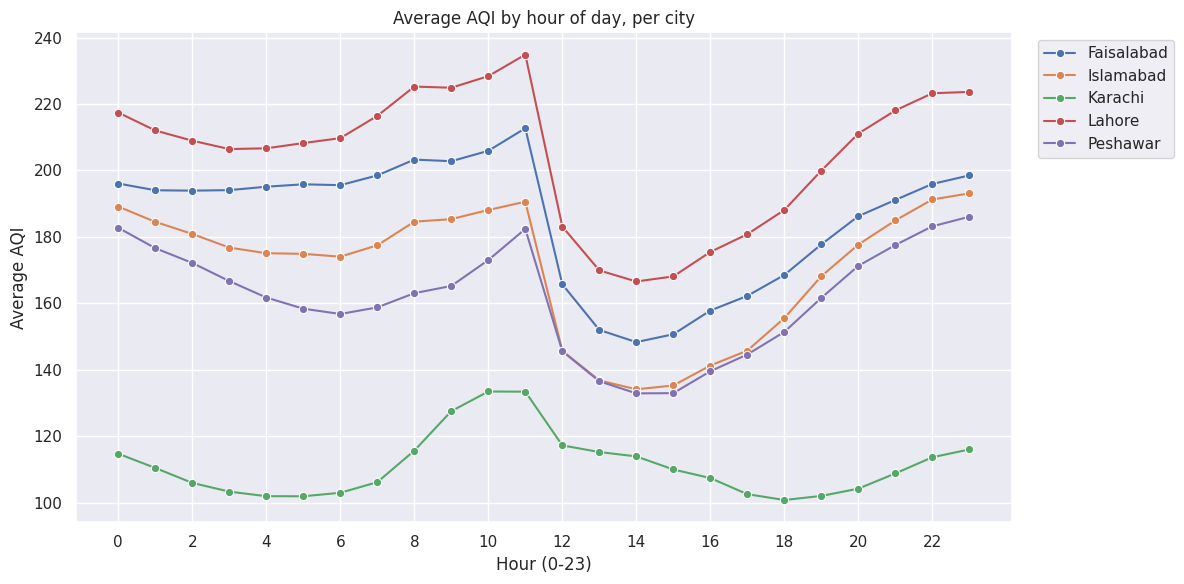

In [ ]:
hourly = df.groupby(["city", "hour"])["aqi"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly, x="hour", y="aqi", hue="city", marker="o")
plt.title("Average AQI by hour of day, per city")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24, 2))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


This is the pattern that justifies including `hour_sin`/`hour_cos` as model features in the first place. If AQI reliably dips or spikes at particular hours (traffic-driven morning/evening peaks are typical), the model needs that signal, and cyclical encoding is the right way to give it that without creating a false discontinuity between hour 23 and hour 0.

## 6. Correlations between pollutants, weather, and AQI

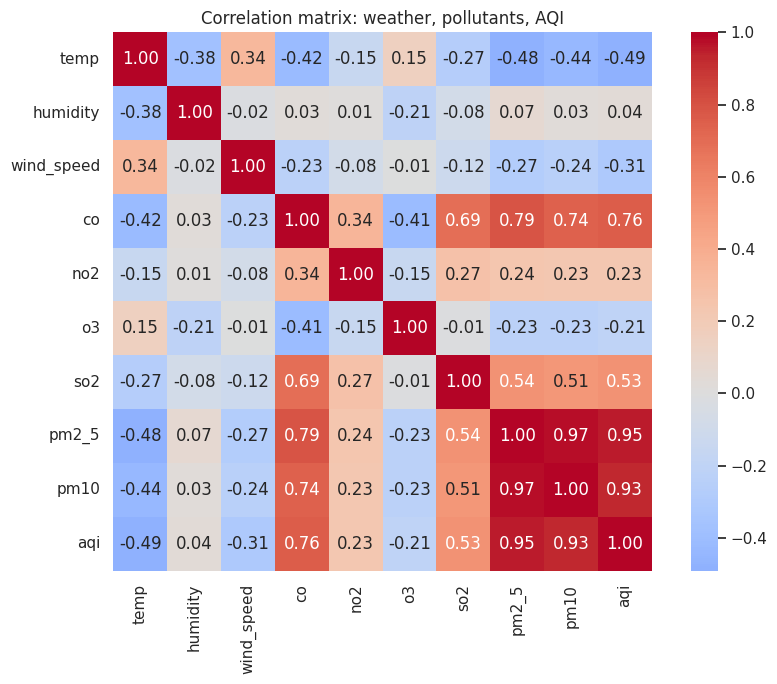

In [ ]:
corr_cols = ["temp", "humidity", "wind_speed", "co", "no2", "o3", "so2", "pm2_5", "pm10", "aqi"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix: weather, pollutants, AQI")
plt.tight_layout()
plt.show()


`pm2_5` and `pm10` should dominate the correlation with `aqi`, which is expected since `calculate_aqi()` derives AQI directly from those two. What's more informative here is how strongly the other pollutants (`co`, `no2`, `so2`) and weather variables (`wind_speed`, `humidity`) correlate with `pm2_5`/`pm10` themselves, that's the signal the model actually has to work with once particulate readings from further back start losing predictive power at longer horizons.

## 7. How predictable is AQI from its own recent history?

In [ ]:
horizons = {"Current -> 24h": "target_aqi_24h", "Current -> 48h": "target_aqi_48h", "Current -> 72h": "target_aqi_72h"}

persistence_corr = {}
for label, col in horizons.items():
    valid = df.dropna(subset=[col])
    persistence_corr[label] = valid["aqi"].corr(valid[col])

print("Correlation between current AQI and future AQI:")
for label, r in persistence_corr.items():
    print(f"  {label}: r = {r:.3f}")


Correlation between current AQI and future AQI:
  Current -> 24h: r = 0.825
  Current -> 48h: r = 0.748
  Current -> 72h: r = 0.702


This is the empirical justification for the persistence baseline in `train.py` (`evaluate_baseline`, which just predicts "future AQI = current AQI"). If current AQI still correlates strongly with AQI 72 hours out, a naive persistence guess is a genuinely hard baseline to beat, not a strawman, which is exactly why comparing every trained model's RMSE against it matters. The actual training run results (see `train_log.txt` and the training pipeline logs) show Random Forest beating this baseline at all three horizons, which is the real evidence the models are learning something beyond "assume no change."

## 8. City comparison summary

In [ ]:
summary = df.groupby("city").agg(
    avg_aqi=("aqi", "mean"),
    avg_pm2_5=("pm2_5", "mean"),
    avg_pm10=("pm10", "mean"),
    avg_temp=("temp", "mean"),
    avg_wind_speed=("wind_speed", "mean"),
).round(1).sort_values("avg_aqi", ascending=False)

summary


,avg_aqi,avg_pm2_5,avg_pm10,avg_temp,avg_wind_speed
city,,,,,
Lahore,204.5,131.6,172.7,24.3,5.9
Faisalabad,185.1,106.1,154.3,25.3,6.5
Islamabad,170.5,91.7,125.4,22.0,6.5
Peshawar,161.7,86.6,126.1,22.3,4.2
Karachi,111.2,49.9,104.3,26.7,11.7


## Key takeaways

- AQI across all five cities skews well above "Good"/"Moderate" for most of the dataset, consistent with known regional air quality, not a pipeline artifact.
- There's a visible seasonal pattern (worth confirming against the chart above per city), which is the real-world signal the `month` feature is meant to capture.
- There's a visible daily pattern by hour, which is what `hour_sin`/`hour_cos` are meant to capture.
- Current AQI correlates strongly with AQI 24-72 hours out, meaning the persistence baseline in `train.py` is a legitimately hard bar to beat, and the trained models beating it (see training logs) is real evidence of learned signal, not just an easy baseline being cleared.
- `pm2_5` and `pm10` dominate the AQI relationship by construction; the more interesting modeling signal comes from how weather and the other pollutants relate to particulate levels themselves, which is what lets the model forecast rather than just recompute the current value.
